# ANP Multi-Redshift Model Diagnostics

This notebook probes the trained ANP to diagnose **why multi-redshift emulation degrades**:

1. **Mean Model Quality per Snapshot** — Is the redshift-agnostic mean prior biasing residuals?
2. **Residual Distribution Analysis** — Are normalized residuals well-behaved per snapshot?
3. **Temporal Embedding Analysis** — Are time embeddings differentiated or collapsed?
4. **Network Capacity / Saturation** — Is the latent space utilized? Is the decoder saturated?
5. **Per-Snapshot Prediction Breakdown** — Where is quality worst?
6. **Hyperparameter Sensitivity** — Which knobs have the most leverage?

In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on the path so anp_emulator and train_anp_emulator are importable
sys.path.insert(0, str(Path('..').resolve()))


In [1]:
import sys, json, math
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn.functional as F

from anp_emulator import Emulator
from train_anp_emulator import (
    MeanModel, StrongANP, build_tasks, split_tasks,
    flatten_family_tasks, remap_flat_tasks_to_families,
    compute_norm_stats, normalize_tasks,
    apply_residual_prior, load_theta_table, denorm_y,
    add_mean_back, restore_all_profiles_physical_units,
    anp_collate, CAMELSRunFamilyDataset,
)
from torch.utils.data import DataLoader
import functools

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

%matplotlib inline

In [2]:
# ── Configuration ──────────────────────────────────────────────────
# Point to whichever run you want to diagnose.
RUN_DIR = Path('anp_training_runs/anp_all_profiles_20260320_064700')
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'

emu = Emulator.from_run_dir(RUN_DIR, device=DEVICE)
run_args = dict(emu.args)

model      = emu.model
mean_model = emu.mean_model

print(f'Run: {RUN_DIR}')
print(f'Device: {DEVICE}')
print(f'Fields: {emu.target_names}')
print(f'Snapshots: {emu.snapnums}')
print(f'Redshifts: {emu.redshift_by_snap}')
print(f'Mean model use_redshift: {mean_model.use_redshift if mean_model else "N/A"}')
print(f'Time feature scale: {model.time_feature_scale}')
print(f'Num snapshots: {model.num_snapshots}')
print(f'Raw x dim: {model.raw_x_dim}')

Run: anp_training_runs/anp_all_profiles_20260320_064700
Device: cuda
Fields: ['gas_density', 'temperature', 'pressure']
Snapshots: [90]
Redshifts: {90: 0.0, 74: 0.5, 60: 1.0, 44: 2.0}
Mean model use_redshift: False
Time feature scale: 0.5
Num snapshots: 1
Raw x dim: 38


## 1. Rebuild Training Data

We reconstruct train/val/test tasks using the same args so we can probe the mean model
and residual distributions on the exact data the model was trained on.

In [3]:
# Reconstruct the args namespace needed by build_tasks.
rebuild_args = SimpleNamespace(**run_args)

# Ensure resolved_snapnums and redshift_by_snap are set.
if not hasattr(rebuild_args, 'resolved_snapnums') or rebuild_args.resolved_snapnums is None:
    rebuild_args.resolved_snapnums = rebuild_args.snapnums or [rebuild_args.snapnum]

# Ensure redshift_by_snap has int keys (JSON serializes dict keys as strings).\nrbs_raw = getattr(rebuild_args, 'redshift_by_snap', None) or {}\nrebuild_args.redshift_by_snap = {int(k): float(v) for k, v in rbs_raw.items()}

# Resolve all_profile_targets
if not hasattr(rebuild_args, 'resolved_all_profile_targets'):
    rebuild_args.resolved_all_profile_targets = run_args.get('all_profiles_subset', None) or emu.target_names

# Defaults for optional args
for attr, default in [
    ('eps', 1e-30), ('r500_physical_factor', 1.0), ('theta_start_idx', 2),
    ('theta_dim', 35), ('radial_stride', 1), ('max_halos_per_run', 128),
    ('min_halos', 2), ('min_snapshots_per_run', 1), ('seed', 42),
    ('max_runs', 1024), ('use_continuous_redshift_feature', False),
    ('redshift_feature_idx', 37),
]:
    if not hasattr(rebuild_args, attr):
        setattr(rebuild_args, attr, run_args.get(attr, default))

print('Building tasks...')
all_families = build_tasks(rebuild_args)
print(f'Total families: {len(all_families)}')

train_frac = float(run_args.get('train_frac', 0.8))
val_frac   = float(run_args.get('val_frac', 0.1))
seed       = int(run_args.get('seed', 42))

train_raw, val_raw, test_raw = split_tasks(all_families, train_frac, val_frac, seed)

# Count snapshots per split
for name, split in [('Train', train_raw), ('Val', val_raw), ('Test', test_raw)]:
    n_fam = len(split)
    snap_counts = {}
    for fam in split:
        for s in fam.snapshots:
            snap_counts[s.snapnum] = snap_counts.get(s.snapnum, 0) + 1
    print(f'{name}: {n_fam} families, snapshot counts: {dict(sorted(snap_counts.items()))}')

Building tasks...
Built 1009 run families (1009 snapshots) from 1012 discovered runs (skipped 3).
Example family run_id=0, snapshots=1, x=(128, 30, 38), y=(128, 30, 3)
Total families: 1009
Train: 807 families, snapshot counts: {90: 807}
Val: 100 families, snapshot counts: {90: 100}
Test: 102 families, snapshot counts: {90: 102}


## 2. Mean Model Quality per Snapshot

**Key question**: Does the mean model produce unbiased residuals across all redshifts?

If the mean model is z-agnostic, residuals at high-z will be systematically biased (the mean
model learns a z-averaged profile, so it's wrong for every individual z).

In [4]:
# Evaluate mean model predictions vs truth per snapshot.
train_flat = flatten_family_tasks(train_raw)

mean_model_device = next(mean_model.parameters()).device if mean_model else None

snap_mean_stats = []
snap_residual_profiles = {}  # snap -> {field -> (n_pts, n_r) residuals in log-space}

for snap in sorted(set(t.snapnum for t in train_flat)):
    tasks_snap = [t for t in train_flat if t.snapnum == snap]
    z_val = tasks_snap[0].redshift
    
    # Stack all (log_M, log_r) and y for this snapshot
    all_x = np.concatenate([t.x[:, :, :2].reshape(-1, 2) for t in tasks_snap], axis=0)
    all_y = np.concatenate([t.y.reshape(-1, t.y.shape[-1]) for t in tasks_snap], axis=0)
    
    if mean_model is not None:
        with torch.no_grad():
            xb = torch.from_numpy(all_x).to(mean_model_device)
            if mean_model.use_redshift:
                zb = torch.full((xb.shape[0],), z_val, dtype=torch.float32, device=mean_model_device)
                pred = mean_model(xb[:, 0], xb[:, 1], redshift=zb).cpu().numpy()
            else:
                pred = mean_model(xb[:, 0], xb[:, 1]).cpu().numpy()
    else:
        pred = np.zeros_like(all_y)
    
    resid = all_y - pred
    
    for ch_idx, ch_name in enumerate(emu.target_names):
        y_ch = all_y[:, ch_idx]
        p_ch = pred[:, ch_idx]
        r_ch = resid[:, ch_idx]
        
        rmse = float(np.sqrt(np.mean(r_ch ** 2)))
        mean_bias = float(np.mean(r_ch))
        std_resid = float(np.std(r_ch))
        y_range = float(np.std(y_ch))
        frac_var_explained = 1.0 - (std_resid**2 / max(y_range**2, 1e-30))
        
        snap_mean_stats.append({
            'snapnum': snap,
            'redshift': z_val,
            'channel': ch_name,
            'mean_model_rmse': rmse,
            'mean_bias': mean_bias,
            'resid_std': std_resid,
            'y_std': y_range,
            'var_explained': frac_var_explained,
            'n_pts': len(y_ch),
        })

mean_df = pd.DataFrame(snap_mean_stats)
print('=== Mean Model Quality per Snapshot ===')
display(mean_df.pivot_table(
    index=['snapnum', 'redshift'], columns='channel',
    values=['mean_model_rmse', 'mean_bias', 'var_explained'],
).round(4))

=== Mean Model Quality per Snapshot ===


mean_bias                      mean_model_rmse           \
channel          gas_density pressure temperature     gas_density pressure   
snapnum redshift                                                             
90      0.0            0.051   0.0854      0.0995          0.4313   0.5758   

                             var_explained                       
channel          temperature   gas_density pressure temperature  
snapnum redshift                                                 
90      0.0           1.1257        0.8989   0.8889      0.1333

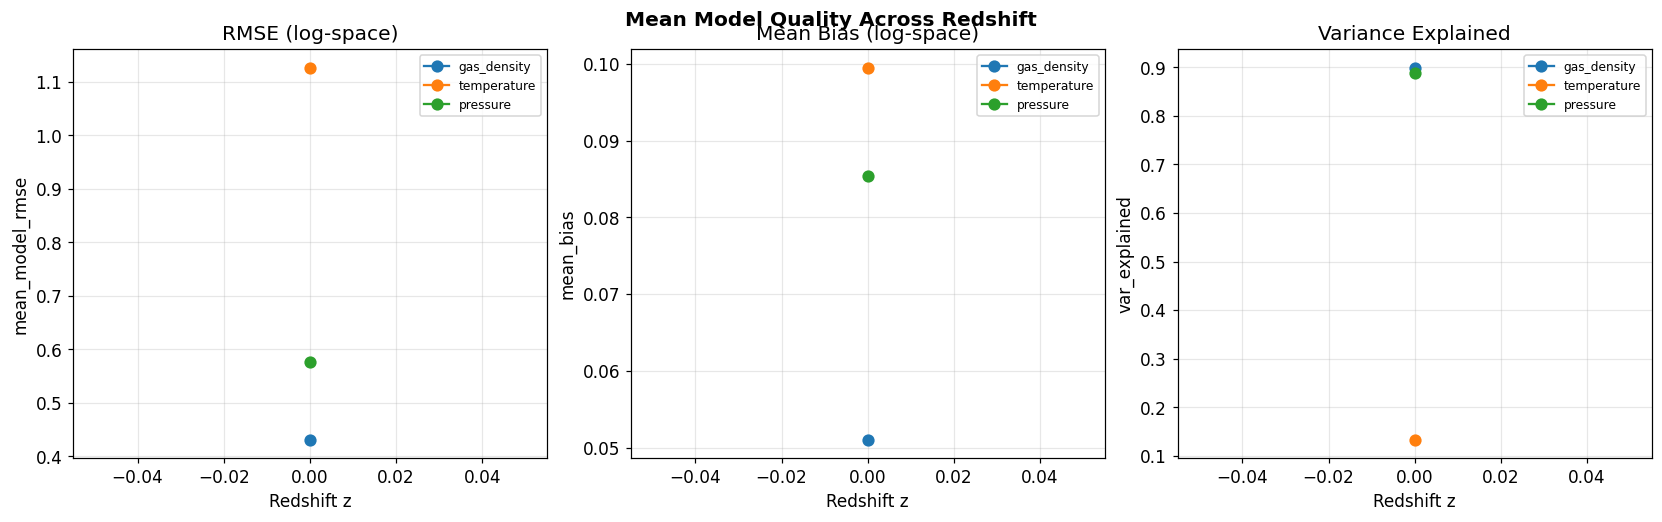


Interpretation:
- If RMSE varies strongly with z → mean model cannot represent z-dependent profiles.
- If bias ≠ 0 → systematic offset in residuals that the ANP must compensate for.
- If var_explained drops at high z → mean model is a poor prior for those snapshots.


In [5]:
# Plot: Mean model RMSE and bias by snapshot for each channel.
channels = emu.target_names
snaps = sorted(mean_df['snapnum'].unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

for ax, metric, title in zip(axes, ['mean_model_rmse', 'mean_bias', 'var_explained'],
                              ['RMSE (log-space)', 'Mean Bias (log-space)', 'Variance Explained']):
    for ch in channels:
        sub = mean_df[mean_df['channel'] == ch]
        ax.plot(sub['redshift'], sub[metric], 'o-', label=ch, markersize=7)
    ax.set_xlabel('Redshift z')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Mean Model Quality Across Redshift', fontweight='bold', y=1.02)
plt.show()

print('\nInterpretation:')
print('- If RMSE varies strongly with z → mean model cannot represent z-dependent profiles.')
print('- If bias ≠ 0 → systematic offset in residuals that the ANP must compensate for.')
print('- If var_explained drops at high z → mean model is a poor prior for those snapshots.')

## 3. Residual Distribution Analysis

After mean subtraction and normalization, the residuals should be roughly standard normal
per channel, regardless of snapshot. If they're not, the ANP sees a **distribution shift** per z.

In [6]:
# Apply mean model and normalization to get the actual residuals the ANP trains on.
if mean_model is not None:
    train_resid = apply_residual_prior(
        train_flat, mean_model,
        device=torch.device(mean_model_device),
        batch_size=262144
    )
else:
    train_resid = train_flat

# Use the normalization stats stored in the checkpoint — these are what
# the model was actually trained with (computed from training residuals).
y_mean_np = emu.y_mean.cpu().numpy()
y_std_np  = emu.y_std.cpu().numpy()
x_mean_np = emu.x_mean.cpu().numpy()
x_std_np  = emu.x_std.cpu().numpy()

norm_stats = {
    'x_mean': x_mean_np, 'x_std': x_std_np,
    'y_mean': y_mean_np, 'y_std': y_std_np,
}

print('Global y_mean (from checkpoint):', y_mean_np)
print('Global y_std  (from checkpoint):', y_std_np)

Global y_mean (from checkpoint): [0.05103948 0.09949975 0.08544818]
Global y_std  (from checkpoint): [0.42783007 1.1180637  0.568796  ]


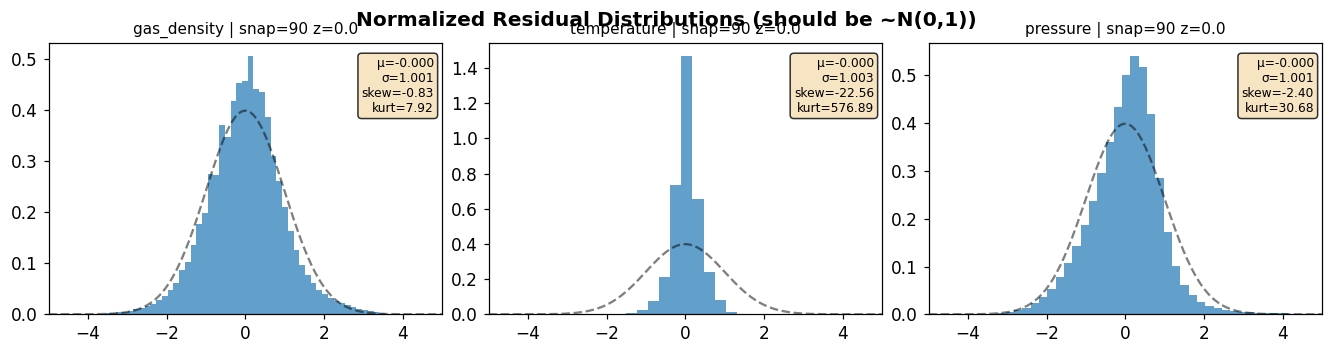

,snapnum,redshift,channel,norm_mean,norm_std,skewness,excess_kurtosis
0,90,0.0,gas_density,-0.0,1.001,-0.829,7.923
1,90,0.0,temperature,-0.0,1.003,-22.561,576.890
2,90,0.0,pressure,-0.0,1.001,-2.398,30.677



Diagnosis:
- norm_mean ≠ 0 → mean model leaves z-dependent bias.
- norm_std ≠ 1 → some snapshots have larger/smaller residuals than the global scale.
- High |skew| or |kurtosis| → non-Gaussian residuals; Gaussian likelihood is mismatched.


In [7]:
# Histogram of normalized residuals per snapshot × channel.
snaps_present = sorted(set(t.snapnum for t in train_resid))
n_snaps = len(snaps_present)
n_ch = len(channels)

fig, axes = plt.subplots(n_snaps, n_ch, figsize=(4 * n_ch, 3 * n_snaps),
                         constrained_layout=True, sharex=True)
if n_snaps == 1:
    axes = axes[None, :]

resid_summary = []
for i_snap, snap in enumerate(snaps_present):
    tasks_snap = [t for t in train_resid if t.snapnum == snap]
    z_val = tasks_snap[0].redshift
    all_y_resid = np.concatenate([t.y.reshape(-1, t.y.shape[-1]) for t in tasks_snap], axis=0)
    
    # Normalize like the training pipeline does
    y_norm = (all_y_resid - y_mean_np[None, :]) / y_std_np[None, :]
    
    for i_ch, ch in enumerate(channels):
        ax = axes[i_snap, i_ch]
        vals = y_norm[:, i_ch]
        vals_clip = vals[np.isfinite(vals)]
        
        ax.hist(vals_clip, bins=100, density=True, alpha=0.7, color=f'C{i_snap}')
        
        # Overlay standard normal
        xx = np.linspace(-5, 5, 200)
        ax.plot(xx, np.exp(-xx**2 / 2) / np.sqrt(2 * np.pi), 'k--', lw=1.5, alpha=0.5)
        
        mu, sigma = np.mean(vals_clip), np.std(vals_clip)
        skew = float(np.mean(((vals_clip - mu) / sigma) ** 3)) if sigma > 0 else 0
        kurt = float(np.mean(((vals_clip - mu) / sigma) ** 4) - 3) if sigma > 0 else 0
        
        ax.set_title(f'{ch} | snap={snap} z={z_val:.1f}', fontsize=10)
        ax.text(0.98, 0.95, f'μ={mu:.3f}\nσ={sigma:.3f}\nskew={skew:.2f}\nkurt={kurt:.2f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        ax.set_xlim(-5, 5)
        
        resid_summary.append({
            'snapnum': snap, 'redshift': z_val, 'channel': ch,
            'norm_mean': mu, 'norm_std': sigma,
            'skewness': skew, 'excess_kurtosis': kurt,
        })

fig.suptitle('Normalized Residual Distributions (should be ~N(0,1))', fontweight='bold', y=1.02)
plt.show()

resid_df = pd.DataFrame(resid_summary)
display(resid_df.round(3))

print('\nDiagnosis:')
print('- norm_mean ≠ 0 → mean model leaves z-dependent bias.')
print('- norm_std ≠ 1 → some snapshots have larger/smaller residuals than the global scale.')
print('- High |skew| or |kurtosis| → non-Gaussian residuals; Gaussian likelihood is mismatched.')

## 4. Temporal Embedding Analysis

Examine whether the learned time embeddings differentiate snapshots meaningfully,
or if they've collapsed (all embeddings similar → no temporal modulation).

In [8]:
if model.time_embedding is not None:
    emb_weights = model.time_embedding.weight.detach().cpu().numpy()  # (num_snap, x_dim)
    n_snap_emb, emb_dim = emb_weights.shape
    
    print(f'Time embedding shape: {emb_weights.shape}')
    print(f'Time feature scale: {model.time_feature_scale}')
    print(f'Effective embedding magnitude: {model.time_feature_scale} × ||emb||')
    print()
    
    # Compute pairwise cosine similarity and L2 distance.
    norms = np.linalg.norm(emb_weights, axis=1)
    cos_sim = emb_weights @ emb_weights.T / (norms[:, None] * norms[None, :] + 1e-12)
    l2_dists = np.sqrt(np.sum((emb_weights[:, None] - emb_weights[None, :]) ** 2, axis=-1))
    
    # Also pass through the time MLP to see effective modulation.
    with torch.no_grad():
        emb_t = model.time_embedding.weight.to(DEVICE)
        mlp_out = model.time_mlp(emb_t).cpu().numpy()  # (num_snap, x_dim)
    
    effective_shift = model.time_feature_scale * mlp_out
    shift_norms = np.linalg.norm(effective_shift, axis=1)
    
    snap_labels = [f'snap{s}\nz={emu.redshift_by_snap.get(s, "?")}'
                   for s in emu.snapnums[:n_snap_emb]]
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)
    
    # 1. Cosine similarity matrix
    im = axes[0].imshow(cos_sim, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[0].set_xticks(range(n_snap_emb)); axes[0].set_xticklabels(snap_labels, fontsize=8)
    axes[0].set_yticks(range(n_snap_emb)); axes[0].set_yticklabels(snap_labels, fontsize=8)
    axes[0].set_title('Embedding Cosine Similarity')
    for i in range(n_snap_emb):
        for j in range(n_snap_emb):
            axes[0].text(j, i, f'{cos_sim[i,j]:.2f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=axes[0], shrink=0.8)
    
    # 2. L2 distance matrix
    im2 = axes[1].imshow(l2_dists, cmap='viridis')
    axes[1].set_xticks(range(n_snap_emb)); axes[1].set_xticklabels(snap_labels, fontsize=8)
    axes[1].set_yticks(range(n_snap_emb)); axes[1].set_yticklabels(snap_labels, fontsize=8)
    axes[1].set_title('Embedding L2 Distance')
    for i in range(n_snap_emb):
        for j in range(n_snap_emb):
            axes[1].text(j, i, f'{l2_dists[i,j]:.2f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im2, ax=axes[1], shrink=0.8)
    
    # 3. Effective shift norm per snapshot (how much does each embedding actually move x?)
    axes[2].bar(range(n_snap_emb), shift_norms, color=[f'C{i}' for i in range(n_snap_emb)])
    axes[2].set_xticks(range(n_snap_emb)); axes[2].set_xticklabels(snap_labels, fontsize=8)
    axes[2].set_ylabel('||time_scale × MLP(emb)||')
    axes[2].set_title('Effective Shift Magnitude')
    
    # Compare to typical x magnitude
    x_std_np = emu.x_std.cpu().numpy()
    typical_x_norm = float(np.linalg.norm(x_std_np))
    axes[2].axhline(typical_x_norm, color='r', ls='--', lw=1.5, label=f'||x_std||={typical_x_norm:.2f}')
    axes[2].legend(fontsize=8)
    
    # 4. PCA of embeddings (2D projection)
    from sklearn.decomposition import PCA
    if n_snap_emb >= 2:
        pca = PCA(n_components=2)
        emb_2d = pca.fit_transform(emb_weights)
        for i in range(n_snap_emb):
            axes[3].scatter(emb_2d[i, 0], emb_2d[i, 1], s=120, c=f'C{i}', zorder=5)
            axes[3].annotate(snap_labels[i], (emb_2d[i, 0], emb_2d[i, 1]),
                           fontsize=8, ha='left', va='bottom')
        axes[3].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
        axes[3].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
        axes[3].set_title('Embedding PCA')
        axes[3].grid(True, alpha=0.3)
    
    fig.suptitle('Temporal Embedding Analysis', fontweight='bold', y=1.02)
    plt.show()
    
    print('\nDiagnosis:')
    print(f'  Effective shift / ||x_std|| ratio: {shift_norms.mean() / max(typical_x_norm, 1e-8):.4f}')
    if shift_norms.mean() / max(typical_x_norm, 1e-8) < 0.05:
        print('  ⚠ Temporal embeddings contribute < 5% of input magnitude.')
        print('    → time_feature_scale is too low; the model can barely distinguish snapshots.')
    
    if np.min(cos_sim[np.triu_indices(n_snap_emb, k=1)]) > 0.8:
        print('  ⚠ All embeddings have cosine similarity > 0.8 → near-collapsed.')
        print('    → Embeddings are not differentiated; temporal conditioning is weak.')
else:
    print('No time embeddings found (single-snapshot model).')

No time embeddings found (single-snapshot model).


## 5. Network Capacity & Saturation Probes

- **Latent space utilization**: Is the KL collapsed? Or does the posterior use the latent space?
- **Task uncertainty**: Per-channel learned noise σ — are channels saturated?
- **FiLM modulation strength**: Does theta conditioning matter?

In [9]:
# Probe latent space: encode validation batches and check KL/posterior stats.
val_flat = flatten_family_tasks(val_raw)

# Build a small validation DataLoader to get real batches.
if mean_model is not None:
    val_resid = apply_residual_prior(
        val_flat, mean_model,
        device=torch.device(mean_model_device),
        batch_size=262144
    )
else:
    val_resid = val_flat

# Re-wrap into families for the collate function
val_resid_fam = remap_flat_tasks_to_families(val_raw, val_resid)
val_norm_fam  = normalize_tasks(val_resid_fam, norm_stats)
val_ds = CAMELSRunFamilyDataset(val_norm_fam)

collate_fn = functools.partial(
    anp_collate,
    max_aux_snapshots=int(run_args.get('max_aux_snapshots', 2)),
    aux_halo_frac=float(run_args.get('aux_halo_frac', 0.5)),
)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)

print(f'Val families: {len(val_ds)}, batches: {len(val_loader)}')

Val families: 100, batches: 50


In [10]:
# Collect latent stats from validation batches.
model.eval()
kl_vals, latent_mu_norms, latent_sigma_means = [], [], []
per_snap_kl = {}
recon_per_snap = {}

n_probe_batches = min(50, len(val_loader))

with torch.no_grad():
    for i_batch, batch in enumerate(val_loader):
        if i_batch >= n_probe_batches:
            break
        
        out = model(batch, device=DEVICE, beta=1.0)
        kl_vals.append(float(out['kl'].cpu()))
        
        # Get latent distribution parameters
        ctx_x_raw = batch['ctx_x'].to(DEVICE)
        ctx_y     = batch['ctx_y'].to(DEVICE)
        ctx_snap  = batch['ctx_snap'].to(DEVICE)
        ctx_mask  = batch['ctx_mask'].to(DEVICE)
        
        ctx_x = model._fuse_time(model._embed_x(ctx_x_raw), ctx_snap)
        q = model.latent(ctx_x, ctx_y, ctx_mask)
        
        latent_mu_norms.append(float(q.loc.norm(dim=-1).mean().cpu()))
        latent_sigma_means.append(float(q.scale.mean().cpu()))
        
        # Track per-snapshot
        for b in range(len(batch['meta'])):
            snap_b = int(batch['meta'][b]['snapnum'])
            per_snap_kl.setdefault(snap_b, []).append(float(out['kl'].cpu()))
            recon_per_snap.setdefault(snap_b, []).append(float(out['rmse_norm'].cpu()))

print('=== Latent Space Statistics ===')
print(f'Mean KL divergence:     {np.mean(kl_vals):.4f}')
print(f'Mean |μ_latent|:        {np.mean(latent_mu_norms):.4f}')
print(f'Mean σ_latent:          {np.mean(latent_sigma_means):.4f}')
print()

if np.mean(latent_sigma_means) > 0.95:
    print('⚠ σ_latent ≈ 1.0 → posterior is near-prior (KL collapsed).')
    print('  The latent code carries almost no information.')
    print('  → The model relies entirely on the deterministic path.')
    print('  → Increase KL warmup or reduce β schedule.')
elif np.mean(kl_vals) < 0.1:
    print('⚠ KL < 0.1 → weak posterior utilization.')
else:
    print('✓ Latent space appears reasonably utilized.')

print()
print('=== Per-Snapshot Breakdown ===')
for snap in sorted(per_snap_kl.keys()):
    z = emu.redshift_by_snap.get(snap, float('nan'))
    kl_s = np.mean(per_snap_kl[snap])
    rmse_s = np.mean(recon_per_snap[snap])
    print(f'  snap={snap} z={z:.1f}: KL={kl_s:.4f}, RMSE(norm)={rmse_s:.4f}')

=== Latent Space Statistics ===
Mean KL divergence:     0.0002
Mean |μ_latent|:        1.3466
Mean σ_latent:          0.2166

⚠ KL < 0.1 → weak posterior utilization.

=== Per-Snapshot Breakdown ===
  snap=90 z=0.0: KL=0.0002, RMSE(norm)=1.3002


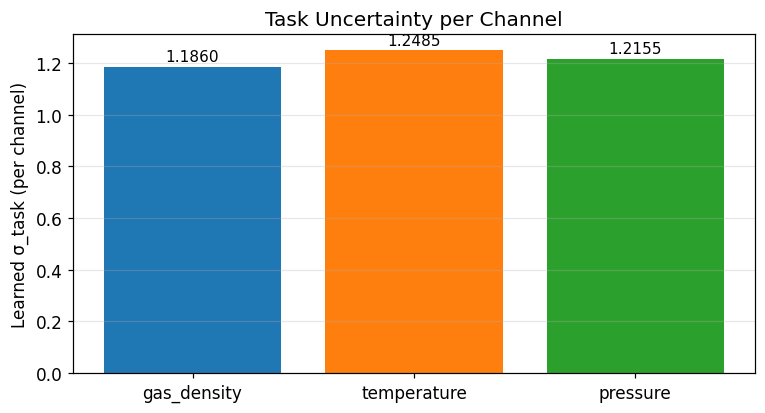


Diagnosis:
- High σ_task → the model treats this channel as noisy / hard to fit.
- If one channel has σ >> others → that channel might be underfitting.


In [11]:
# Per-channel task uncertainty.
if hasattr(model, 'log_sigma_task') and model.log_sigma_task is not None:
    sigma_task = model.log_sigma_task.detach().exp().cpu().numpy()
    
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(emu.target_names, sigma_task, color=[f'C{i}' for i in range(len(sigma_task))])
    ax.set_ylabel('Learned σ_task (per channel)')
    ax.set_title('Task Uncertainty per Channel')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, sigma_task):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    plt.show()
    
    print('\nDiagnosis:')
    print('- High σ_task → the model treats this channel as noisy / hard to fit.')
    print('- If one channel has σ >> others → that channel might be underfitting.')
    ratio = max(sigma_task) / max(min(sigma_task), 1e-8)
    if ratio > 5:
        print(f'  ⚠ σ ratio max/min = {ratio:.1f} → large channel imbalance.')
else:
    print('No per-channel task uncertainty (use_task_uncertainty_weighting=False).')

In [12]:
# FiLM modulation strength analysis.
# Check how much the theta FiLM layers modulate the decoder hidden activations.
dec = model.dec

# Get FiLM layer weights
film_params = []
for name, param in dec.named_parameters():
    if 'theta_film' in name or 'film' in name.lower():
        film_params.append((name, param.detach().cpu()))

if film_params:
    print('=== FiLM Conditioning Weights ===')
    for name, param in film_params:
        print(f'  {name}: shape={list(param.shape)}, '
              f'|mean|={param.abs().mean():.4f}, std={param.std():.4f}, '
              f'||w||={param.norm():.4f}')
    
    print(f'\n  theta_film_scale = {run_args.get("theta_film_scale", "?")}')    
    print('\n  If FiLM weight norms are very small → theta conditioning is weak.')
    print('  The model may not differentiate predictions across cosmological parameters.')
else:
    print('No FiLM parameters found in decoder.')

=== FiLM Conditioning Weights ===
  theta_film.0.weight: shape=[1024, 36], |mean|=0.0852, std=0.0986, ||w||=18.9259
  theta_film.0.bias: shape=[1024], |mean|=0.0817, std=0.0943, ||w||=3.0160
  theta_film.2.weight: shape=[1024, 1024], |mean|=0.0179, std=0.0217, ||w||=22.1944
  theta_film.2.bias: shape=[1024], |mean|=0.0157, std=0.0184, ||w||=0.5887

  theta_film_scale = 0.1

  If FiLM weight norms are very small → theta conditioning is weak.
  The model may not differentiate predictions across cosmological parameters.


## 6. Per-Snapshot Prediction Quality

Run the emulator on a subset of validation data per snapshot and compare RMSE.

=== Per-Snapshot Prediction Quality (Validation Set) ===


,snapnum,redshift,channel,rmse_log10,median_rel_err,n_runs
0,90,0.0,gas_density,0.4077,0.4738,10
1,90,0.0,pressure,0.4851,0.5209,10
2,90,0.0,temperature,0.7447,0.3574,10


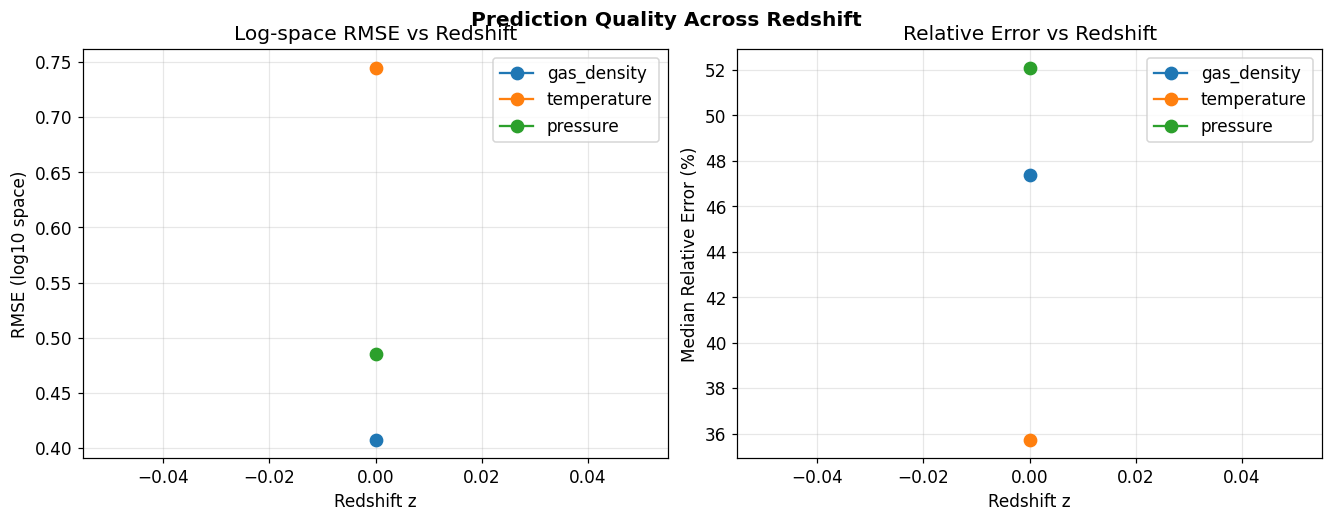

In [13]:
# Per-snapshot emulation quality on validation set.
theta_table = load_theta_table(Path(run_args['param_csv']),
                               target_theta_dim=emu.theta_dim)

pred_quality_rows = []
n_eval_per_snap = 10  # number of runs to evaluate per snapshot

for snap in sorted(set(t.snapnum for t in val_flat)):
    tasks_snap = [t for t in val_flat if t.snapnum == snap][:n_eval_per_snap]
    z_val = tasks_snap[0].redshift
    
    for t in tasks_snap:
        theta = theta_table.get(t.run_id)
        if theta is None:
            continue
        
        masses = 10.0 ** t.x[:, 0, 0]  # log_M → M
        # Reconstruct r/R500 → r_bins in physical units
        r_over_r500 = 10.0 ** t.x[:, :, 1]  # (n_halo, n_r)
        
        pred = emu.predict(
            theta=theta,
            M=masses.astype(np.float32),
            r_bins=r_over_r500.astype(np.float32),
            field=emu.target_names,
            snapnum=int(snap),
            redshift=float(z_val),
            n_samples=20,
        )
        
        # Truth is in log-space for all_profiles; pred is in physical units.
        # Convert truth to physical units for comparison.
        for ch_idx, ch_name in enumerate(emu.target_names):
            y_true_phys = 10.0 ** t.y[:, :, ch_idx]  # log10 → physical
            y_pred_phys = pred.mean[:, :, ch_idx]
            
            # RMSE in log-space (more meaningful for profiles spanning orders of magnitude)
            log_true = np.log10(np.clip(y_true_phys, 1e-30, None))
            log_pred = np.log10(np.clip(y_pred_phys, 1e-30, None))
            rmse_log = float(np.sqrt(np.mean((log_pred - log_true) ** 2)))
            
            # Relative error
            rel_err = np.abs(y_pred_phys - y_true_phys) / np.clip(y_true_phys, 1e-30, None)
            med_rel = float(np.median(rel_err))
            
            pred_quality_rows.append({
                'snapnum': snap, 'redshift': z_val, 'channel': ch_name,
                'run_id': t.run_id,
                'rmse_log10': rmse_log,
                'median_rel_err': med_rel,
                'n_halo': t.n_halo,
            })

pq_df = pd.DataFrame(pred_quality_rows)
if len(pq_df) > 0:
    summary = pq_df.groupby(['snapnum', 'redshift', 'channel']).agg(
        rmse_log10=('rmse_log10', 'mean'),
        median_rel_err=('median_rel_err', 'mean'),
        n_runs=('run_id', 'nunique'),
    ).reset_index()
    
    print('=== Per-Snapshot Prediction Quality (Validation Set) ===')
    display(summary.round(4))
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    for ch in emu.target_names:
        sub = summary[summary['channel'] == ch]
        axes[0].plot(sub['redshift'], sub['rmse_log10'], 'o-', label=ch, markersize=8)
        axes[1].plot(sub['redshift'], sub['median_rel_err'] * 100, 'o-', label=ch, markersize=8)
    
    axes[0].set_xlabel('Redshift z'); axes[0].set_ylabel('RMSE (log10 space)')
    axes[0].set_title('Log-space RMSE vs Redshift'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].set_xlabel('Redshift z'); axes[1].set_ylabel('Median Relative Error (%)')
    axes[1].set_title('Relative Error vs Redshift'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    fig.suptitle('Prediction Quality Across Redshift', fontweight='bold', y=1.02)
    plt.show()
else:
    print('No predictions evaluated (check theta_table matching).')

## 6b. Ideal Gas Law Violation

Check thermodynamic self-consistency: in log10 space, P ≈ ρ_gas × T × C, i.e. `log10(P) = log10(ρ) + log10(T) + log10(C)`. Measure how well the model's predictions satisfy this constraint vs truth.

=== Ideal Gas Law: log10(P) - log10(rho) - log10(T) = log10(C) ===
Expected log10(C) ≈ 4.146  (from simulation data)



,snapnum,redshift,C_true,C_true_scatter,C_pred,C_pred_scatter,delta_bias,delta_rms
0,90,0.0,4.1478,0.482,4.1442,0.0776,-0.0036,0.4861


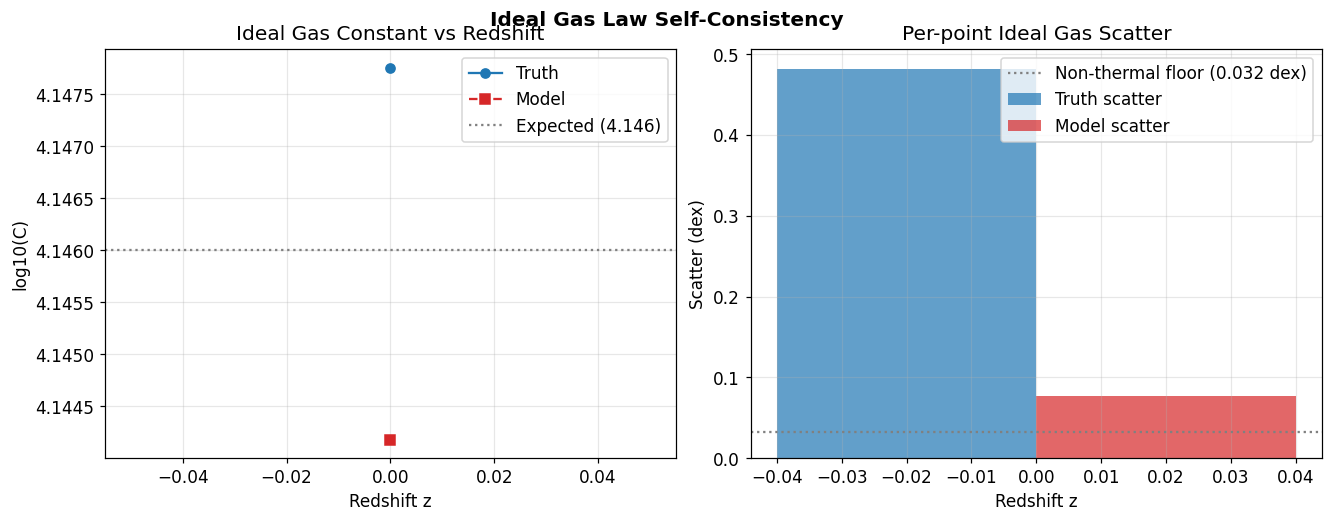


Δ(model−truth) bias: -0.0036 dex
Δ(model−truth)  RMS: 0.4861 dex
⚠ Model violates ideal gas law by >0.1 dex on average.
  → Consider enabling --ideal-gas-weight (e.g. 0.1–1.0)


In [14]:
# Measure ideal gas law violation: log10(P) - log10(rho) - log10(T) = log10(C)
# Compare truth vs model predictions.
_ig_names = ('gas_density', 'temperature', 'pressure')
_ig_present = all(n in emu.target_names for n in _ig_names)

if _ig_present and len(pq_df) > 0:
    rho_idx = emu.target_names.index('gas_density')
    T_idx = emu.target_names.index('temperature')
    P_idx = emu.target_names.index('pressure')

    ig_rows = []
    for snap in sorted(set(t.snapnum for t in val_flat)):
        tasks_snap = [t for t in val_flat if t.snapnum == snap][:n_eval_per_snap]
        z_val = tasks_snap[0].redshift

        for t in tasks_snap:
            theta = theta_table.get(t.run_id)
            if theta is None:
                continue
            masses = 10.0 ** t.x[:, 0, 0]
            r_over_r500 = 10.0 ** t.x[:, :, 1]

            pred = emu.predict(
                theta=theta,
                M=masses.astype(np.float32),
                r_bins=r_over_r500.astype(np.float32),
                field=emu.target_names,
                snapnum=int(snap),
                redshift=float(z_val),
                n_samples=20,
            )

            # Truth in log10 space
            logP_true = t.y[:, :, P_idx]
            logrho_true = t.y[:, :, rho_idx]
            logT_true = t.y[:, :, T_idx]

            # Model predictions → log10  (pred.mean is in physical units)
            logP_pred = np.log10(np.clip(pred.mean[:, :, P_idx], 1e-30, None))
            logrho_pred = np.log10(np.clip(pred.mean[:, :, rho_idx], 1e-30, None))
            logT_pred = np.log10(np.clip(pred.mean[:, :, T_idx], 1e-30, None))

            viol_true = logP_true - logrho_true - logT_true
            viol_pred = logP_pred - logrho_pred - logT_pred

            ig_rows.append({
                'snapnum': snap, 'redshift': z_val, 'run_id': t.run_id,
                'C_true_mean': float(np.mean(viol_true)),
                'C_true_std':  float(np.std(viol_true)),
                'C_pred_mean': float(np.mean(viol_pred)),
                'C_pred_std':  float(np.std(viol_pred)),
                'delta_mean':  float(np.mean(viol_pred - viol_true)),
                'delta_rms':   float(np.sqrt(np.mean((viol_pred - viol_true) ** 2))),
            })

    ig_df = pd.DataFrame(ig_rows)
    ig_summary = ig_df.groupby(['snapnum', 'redshift']).agg(
        C_true=('C_true_mean', 'mean'),
        C_true_scatter=('C_true_std', 'mean'),
        C_pred=('C_pred_mean', 'mean'),
        C_pred_scatter=('C_pred_std', 'mean'),
        delta_bias=('delta_mean', 'mean'),
        delta_rms=('delta_rms', 'mean'),
    ).reset_index()

    print('=== Ideal Gas Law: log10(P) - log10(rho) - log10(T) = log10(C) ===')
    print(f'Expected log10(C) ≈ 4.146  (from simulation data)\n')
    display(ig_summary.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    axes[0].plot(ig_summary['redshift'], ig_summary['C_true'], 'o-', label='Truth', color='C0')
    axes[0].plot(ig_summary['redshift'], ig_summary['C_pred'], 's--', label='Model', color='C3')
    axes[0].axhline(4.146, ls=':', color='grey', label='Expected (4.146)')
    axes[0].set_xlabel('Redshift z'); axes[0].set_ylabel('log10(C)')
    axes[0].set_title('Ideal Gas Constant vs Redshift')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].bar(ig_summary['redshift'] - 0.02, ig_summary['C_true_scatter'],
                width=0.04, label='Truth scatter', alpha=0.7, color='C0')
    axes[1].bar(ig_summary['redshift'] + 0.02, ig_summary['C_pred_scatter'],
                width=0.04, label='Model scatter', alpha=0.7, color='C3')
    axes[1].axhline(0.032, ls=':', color='grey', label='Non-thermal floor (0.032 dex)')
    axes[1].set_xlabel('Redshift z'); axes[1].set_ylabel('Scatter (dex)')
    axes[1].set_title('Per-point Ideal Gas Scatter')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    fig.suptitle('Ideal Gas Law Self-Consistency', fontweight='bold', y=1.02)
    plt.show()

    print(f'\nΔ(model−truth) bias: {ig_df["delta_mean"].mean():.4f} dex')
    print(f'Δ(model−truth)  RMS: {ig_df["delta_rms"].mean():.4f} dex')
    if ig_df['delta_rms'].mean() > 0.1:
        print('⚠ Model violates ideal gas law by >0.1 dex on average.')
        print('  → Consider enabling --ideal-gas-weight (e.g. 0.1–1.0)')
    else:
        print('✓ Model predictions are thermodynamically self-consistent.')
else:
    if not _ig_present:
        print(f'Skipped: need gas_density, temperature, pressure in target_names.')
        print(f'Current targets: {emu.target_names}')
    else:
        print('Skipped: no prediction data available (pq_df empty).')

## 7. Decoder Gradient Saturation Check

Pass synthetic data through the network and check if gradients vanish in the decoder.
This tests whether the network has the **capacity** to improve — if gradients are near-zero,
the model is stuck regardless of how long you train.

In [15]:
# Gradient magnitude analysis per layer group.
model.train()  # Enable gradients

# Get one real batch
probe_batch = next(iter(val_loader))
out = model(probe_batch, device=DEVICE, beta=1.0)
out['loss'].backward()

grad_stats = []
for name, param in model.named_parameters():
    if param.grad is not None:
        g = param.grad.detach().cpu()
        grad_stats.append({
            'layer': name,
            'param_norm': float(param.detach().cpu().norm()),
            'grad_norm': float(g.norm()),
            'grad_mean_abs': float(g.abs().mean()),
            'grad_max': float(g.abs().max()),
            'ratio': float(g.norm() / max(param.detach().cpu().norm(), 1e-12)),
        })

model.eval()
model.zero_grad()

grad_df = pd.DataFrame(grad_stats)

# Group by component
def _component(name):
    if 'time_' in name: return 'time_embedding'
    if 'latent' in name: return 'latent_encoder'
    if 'det' in name: return 'det_encoder'
    if 'dec' in name or 'theta_film' in name: return 'decoder'
    if 'log_sigma' in name: return 'task_sigma'
    return 'other'

grad_df['component'] = grad_df['layer'].apply(_component)

comp_summary = grad_df.groupby('component').agg(
    mean_grad_norm=('grad_norm', 'mean'),
    mean_ratio=('ratio', 'mean'),
    max_grad=('grad_max', 'max'),
    n_params=('layer', 'count'),
).round(6)

print('=== Gradient Flow by Component ===')
display(comp_summary)

print('\nDiagnosis:')
for comp, row in comp_summary.iterrows():
    if row['mean_ratio'] < 1e-5:
        print(f'  ⚠ {comp}: grad/param ratio = {row["mean_ratio"]:.2e} → near-vanishing gradients.')
    elif row['mean_ratio'] > 1.0:
        print(f'  ⚠ {comp}: grad/param ratio = {row["mean_ratio"]:.2e} → exploding gradients.')
    else:
        print(f'  ✓ {comp}: grad/param ratio = {row["mean_ratio"]:.2e} → healthy.')

=== Gradient Flow by Component ===


,mean_grad_norm,mean_ratio,max_grad,n_params
component,,,,
decoder,2.182348,9.393055,5.486893,30
det_encoder,0.854151,0.842128,0.753536,70
latent_encoder,0.084977,0.102954,0.085252,50
task_sigma,0.233867,0.685338,0.217107,1



Diagnosis:
  ⚠ decoder: grad/param ratio = 9.39e+00 → exploding gradients.
  ✓ det_encoder: grad/param ratio = 8.42e-01 → healthy.
  ✓ latent_encoder: grad/param ratio = 1.03e-01 → healthy.
  ✓ task_sigma: grad/param ratio = 6.85e-01 → healthy.


## 8. Model Parameter Count & Capacity Budget

Check total parameters and how they're distributed. Compare to the data size to
assess whether the model is over- or under-parameterized.

In [16]:
# Parameter count breakdown.
param_counts = {}
for name, param in model.named_parameters():
    comp = _component(name)
    param_counts[comp] = param_counts.get(comp, 0) + param.numel()

total_params = sum(param_counts.values())
mean_params = sum(p.numel() for p in mean_model.parameters()) if mean_model else 0

# Data size
total_train_points = sum(t.n_halo * t.n_r for t in train_flat)
n_channels = len(emu.target_names)

print('=== Model Capacity Budget ===')
print(f'\nStrongANP parameters:')
for comp, count in sorted(param_counts.items(), key=lambda x: -x[1]):
    print(f'  {comp:20s}: {count:>10,d} ({100*count/total_params:.1f}%)')
print(f'  {"TOTAL":20s}: {total_params:>10,d}')
print(f'\nMean model parameters:  {mean_params:>10,d}')
print(f'Grand total:            {total_params + mean_params:>10,d}')

print(f'\n=== Data Budget ===')
print(f'Training points (halo × radius): {total_train_points:,d}')
print(f'Output channels: {n_channels}')
print(f'Effective data values: {total_train_points * n_channels:,d}')
print(f'Params / data ratio: {(total_params + mean_params) / max(1, total_train_points * n_channels):.4f}')

ratio = (total_params + mean_params) / max(1, total_train_points * n_channels)
if ratio > 0.5:
    print('\n⚠ Params/data > 0.5 → model may be overparameterized.')
    print('  Risk of overfitting; consider more regularization or smaller model.')
elif ratio < 0.01:
    print('\n⚠ Params/data < 0.01 → model may be underparameterized.')
    print('  Consider increasing d_model, dec_hidden, or dec_layers.')
else:
    print(f'\n✓ Params/data ratio looks reasonable ({ratio:.4f}).')

=== Model Capacity Budget ===

StrongANP parameters:
  det_encoder         :  3,133,184 (37.5%)
  decoder             :  2,641,926 (31.6%)
  latent_encoder      :  2,586,624 (30.9%)
  task_sigma          :          3 (0.0%)
  TOTAL               :  8,361,737

Mean model parameters:      67,331
Grand total:             8,429,068

=== Data Budget ===
Training points (halo × radius): 2,281,020
Output channels: 3
Effective data values: 6,843,060
Params / data ratio: 1.2318

⚠ Params/data > 0.5 → model may be overparameterized.
  Risk of overfitting; consider more regularization or smaller model.


## 9. Training History Analysis

If the run has a history file, visualize convergence curves and per-snapshot metrics.

Loaded 430 epochs of training history.


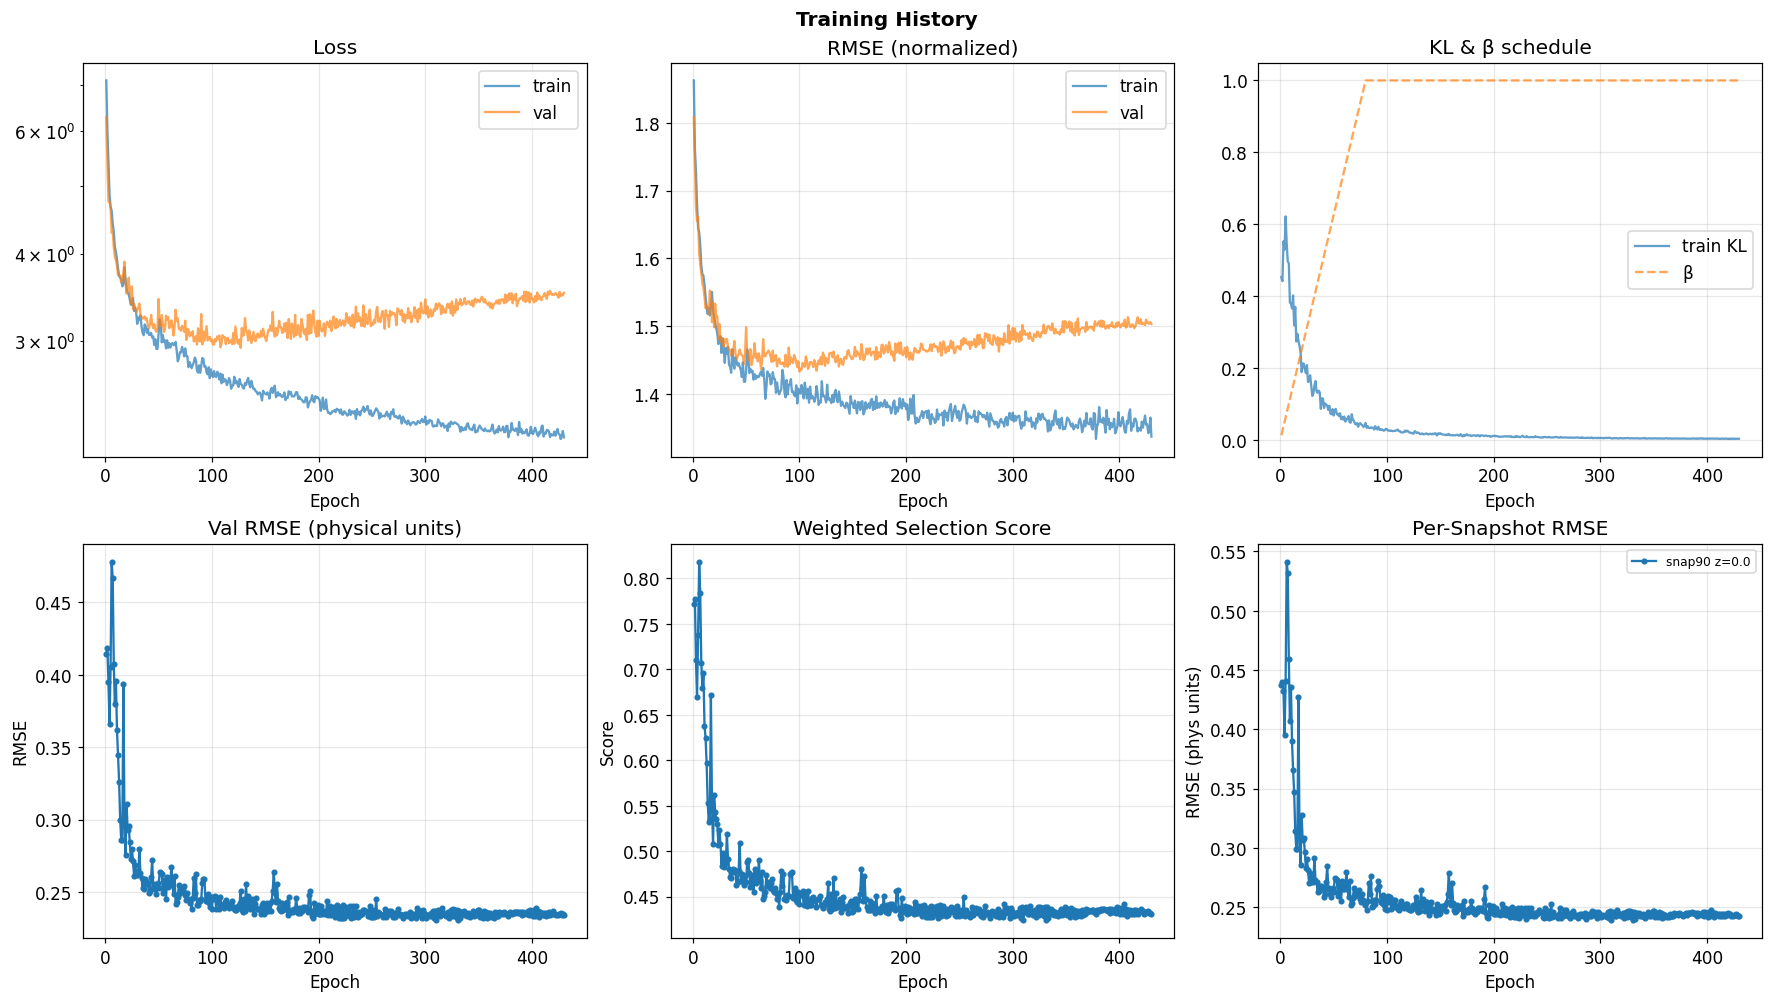


Val loss trend (last 20 epochs): slope = 0.000179
  ⚠ Val loss increasing → possible overfitting.


In [17]:
# Load training history.
history_path = RUN_DIR / 'history.json'
if history_path.exists():
    with open(history_path) as f:
        history = json.load(f)
    hist_df = pd.DataFrame(history)
    print(f'Loaded {len(hist_df)} epochs of training history.')
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    
    # Row 1: Standard training curves
    axes[0, 0].plot(hist_df['epoch'], hist_df['train_loss'], label='train', alpha=0.7)
    axes[0, 0].plot(hist_df['epoch'], hist_df['val_loss'], label='val', alpha=0.7)
    axes[0, 0].set_title('Loss'); axes[0, 0].legend(); axes[0, 0].set_yscale('log')
    
    axes[0, 1].plot(hist_df['epoch'], hist_df['train_rmse_norm'], label='train', alpha=0.7)
    axes[0, 1].plot(hist_df['epoch'], hist_df['val_rmse_norm'], label='val', alpha=0.7)
    axes[0, 1].set_title('RMSE (normalized)'); axes[0, 1].legend()
    
    axes[0, 2].plot(hist_df['epoch'], hist_df['train_kl'], label='train KL', alpha=0.7)
    axes[0, 2].plot(hist_df['epoch'], hist_df['beta'], label='β', alpha=0.7, ls='--')
    axes[0, 2].set_title('KL & β schedule'); axes[0, 2].legend()
    
    # Row 2: Detailed metrics (if available)
    if 'val_rmse_original_units' in hist_df.columns:
        valid = hist_df['val_rmse_original_units'].notna()
        axes[1, 0].plot(hist_df.loc[valid, 'epoch'], hist_df.loc[valid, 'val_rmse_original_units'], 'o-', ms=3)
        axes[1, 0].set_title('Val RMSE (physical units)'); axes[1, 0].set_ylabel('RMSE')
    
    if 'val_weighted_orig' in hist_df.columns:
        valid = hist_df['val_weighted_orig'].notna()
        axes[1, 1].plot(hist_df.loc[valid, 'epoch'], hist_df.loc[valid, 'val_weighted_orig'], 'o-', ms=3)
        axes[1, 1].set_title('Weighted Selection Score'); axes[1, 1].set_ylabel('Score')
    
    # Per-snapshot RMSE if available
    snap_cols = [c for c in hist_df.columns if c.startswith('val_snap') and c.endswith('_rmse')]
    if snap_cols:
        for col in snap_cols:
            valid = hist_df[col].notna()
            snap_num = col.replace('val_snap', '').replace('_rmse', '')
            z = emu.redshift_by_snap.get(int(snap_num), '?')
            axes[1, 2].plot(hist_df.loc[valid, 'epoch'], hist_df.loc[valid, col],
                          'o-', ms=3, label=f'snap{snap_num} z={z}')
        axes[1, 2].set_title('Per-Snapshot RMSE'); axes[1, 2].legend(fontsize=8)
        axes[1, 2].set_ylabel('RMSE (phys units)')
    else:
        axes[1, 2].text(0.5, 0.5, 'No per-snapshot metrics\n(pre-fix run)',
                       ha='center', va='center', transform=axes[1, 2].transAxes)
    
    for ax in axes.flat:
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    
    fig.suptitle('Training History', fontweight='bold')
    plt.show()
    
    # Convergence analysis
    last_20 = hist_df.tail(20)
    val_loss_trend = np.polyfit(last_20['epoch'], last_20['val_loss'], 1)[0]
    print(f'\nVal loss trend (last 20 epochs): slope = {val_loss_trend:.6f}')
    if abs(val_loss_trend) < 1e-4:
        print('  ✓ Training appears converged (flat loss).')
    elif val_loss_trend > 0:
        print('  ⚠ Val loss increasing → possible overfitting.')
    else:
        print('  → Still improving; more epochs could help.')
else:
    print(f'No history.json found in {RUN_DIR}.')
    print('(Training may still be in progress.)')

## 10. Hyperparameter Sensitivity Summary

Synthesize all the diagnostics into actionable recommendations.

In [18]:
# Compile all diagnoses.
print('=' * 70)
print('DIAGNOSTIC SUMMARY')
print('=' * 70)

print('\n[1] MEAN MODEL')
if mean_model is not None:
    print(f'  use_redshift: {mean_model.use_redshift}')
    if not mean_model.use_redshift:
        bias_range = mean_df.groupby('snapnum')['mean_bias'].apply(lambda x: x.abs().max()).max()
        print(f'  ⚠ NOT conditioned on redshift. Max |bias| across snaps: {bias_range:.4f}')
        print('  → FIX: Retrain with redshift-aware mean model (already implemented).')
    else:
        print('  ✓ Conditioned on redshift.')
    
    worst_ve = mean_df.groupby('snapnum')['var_explained'].min().min()
    print(f'  Worst variance explained: {worst_ve:.4f}')
    if worst_ve < 0.5:
        print(f'  ⚠ Mean model explains < 50% variance for some snapshot/channel.')
        print(f'  → Increase --mean-hidden-dim (current: {run_args.get("mean_hidden_dim", 128)})')
        print(f'  → Increase --mean-epochs (current: {run_args.get("mean_epochs", 80)})')

print('\n[2] TEMPORAL CONDITIONING')
if model.time_embedding is not None:
    eff_ratio = shift_norms.mean() / max(typical_x_norm, 1e-8)
    print(f'  time_feature_scale: {model.time_feature_scale}')
    print(f'  Effective shift / ||x_std||: {eff_ratio:.4f}')
    if eff_ratio < 0.05:
        print(f'  ⚠ Very weak temporal modulation.')
        print(f'  → Increase --time-feature-scale to 0.5 or higher.')
else:
    print('  Single snapshot model (no temporal conditioning).')

print('\n[3] LATENT SPACE')
print(f'  d_latent: {run_args.get("d_latent", "?")}')
print(f'  Mean KL: {np.mean(kl_vals):.4f}, Mean σ_latent: {np.mean(latent_sigma_means):.4f}')
if np.mean(latent_sigma_means) > 0.9:
    print(f'  ⚠ Near-collapsed posterior. Model relies on deterministic path.')
    print(f'  → Increase --kl-warmup-epochs (current: {run_args.get("kl_warmup_epochs", 80)})')

print('\n[4] NORMALIZED RESIDUALS')
worst_bias = resid_df.loc[resid_df['norm_mean'].abs().idxmax()]
worst_std = resid_df.loc[(resid_df['norm_std'] - 1.0).abs().idxmax()]
print(f'  Worst bias: snap={worst_bias["snapnum"]} {worst_bias["channel"]} μ={worst_bias["norm_mean"]:.3f}')
print(f'  Worst std deviation from 1: snap={worst_std["snapnum"]} {worst_std["channel"]} σ={worst_std["norm_std"]:.3f}')
if abs(worst_bias['norm_mean']) > 0.3:
    print(f'  ⚠ Large bias → mean model + normalization leaves snapshot-dependent offset.')
if abs(worst_std['norm_std'] - 1.0) > 0.3:
    print(f'  ⚠ Std far from 1.0 → residual scale varies by snapshot.')
    print(f'  → Consider per-snapshot normalization or stronger mean model.')

print('\n[5] DECODER CAPACITY')
print(f'  dec_hidden: {run_args.get("dec_hidden", "?")}')
print(f'  dec_layers: {run_args.get("dec_layers", "?")}')
dec_params = param_counts.get('decoder', 0)
print(f'  Decoder parameters: {dec_params:,d} ({100*dec_params/total_params:.1f}% of total)')

print('\n[6] TRAINING DYNAMICS')
print(f'  lr: {run_args.get("lr", "?")}')
print(f'  batch_size × accum_steps: {run_args.get("batch_size", "?")} × {run_args.get("accum_steps", "?")}')
print(f'  patience: {run_args.get("patience", "?")}')
print(f'  epochs: {run_args.get("epochs", "?")}')

print('\n' + '=' * 70)
print('RECOMMENDED PRIORITY CHANGES (based on diagnostics)')
print('=' * 70)

DIAGNOSTIC SUMMARY

[1] MEAN MODEL
  use_redshift: False
  ⚠ NOT conditioned on redshift. Max |bias| across snaps: 0.0995
  → FIX: Retrain with redshift-aware mean model (already implemented).
  Worst variance explained: 0.1333
  ⚠ Mean model explains < 50% variance for some snapshot/channel.
  → Increase --mean-hidden-dim (current: 256)
  → Increase --mean-epochs (current: 150)

[2] TEMPORAL CONDITIONING
  Single snapshot model (no temporal conditioning).

[3] LATENT SPACE
  d_latent: 128
  Mean KL: 0.0002, Mean σ_latent: 0.2166

[4] NORMALIZED RESIDUALS
  Worst bias: snap=90 pressure μ=-0.000
  Worst std deviation from 1: snap=90 temperature σ=1.003

[5] DECODER CAPACITY
  dec_hidden: 512
  dec_layers: 5
  Decoder parameters: 2,641,926 (31.6% of total)

[6] TRAINING DYNAMICS
  lr: 0.0003
  batch_size × accum_steps: 2 × 16
  patience: 120
  epochs: 500

RECOMMENDED PRIORITY CHANGES (based on diagnostics)
